# Tranformer From Scratch

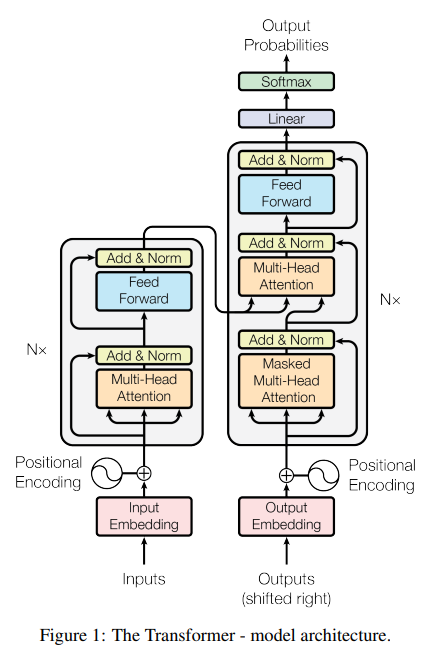

In [4]:
import torch
import torch.nn as nn
import math

## Input Embedding using Default nn.Embedding

In [5]:
class InputEmbeddings(nn.Module):
    def __init__(self, d_model: int, vocab_size: int ):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

## Positional Encoding
Encodes positional data of a particular word in a sentence
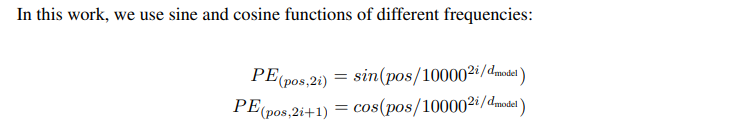

In [7]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None: 
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout) #to make the model less overfit

        #Create a matrix of shape (seq_len, d_model)
        pe = torch.zero(seq_len, d_model)

        #Crate a vector of shape (seq_len)  
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        #Apply sin to even
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0) #(1, seq_len, d_model)

        self.register_buffer('pe', pe)     #this will be saved in the model when training
        
    def forward(self, x): 
        x = x + (self.pe[:, x.shape[1], :]).requires_grad_(False)    #Note Learnt
        return self.dropout(x)

## Layer Normalization

In [6]:
class LayerNormalization(nn.Module):
    def __init__(self, eps: float = 10**-6) -> None:
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(1))    #Multiplied
        self.bias = nn.Parameter(torch.zeros(1))    #Added

    def foward(self, x):
        mean = x.mean(dim = -1, keepdim = True)     #dim = -1 means calculate each batch (mean of last dimension)
        std = x.std(dim = -1, keepdim = True)
        return self.alpha * (x - mean) / (std + self.eps) + self.bias

## Feed Forward Layer (FCN)
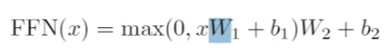

In [9]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout:float) -> None:
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff, bias = True) #w1 + b1
        self.dropout = nn.Dropout(dropout)
        self.w2 = nn.Linear(d_ff, d_model, bias = True) #w2 + b2

    def forward(self, x): 
        # (batch_size, seq_len, d_model) --> (batch_size, seq_len, d_ff) --> (batch_size, seq_len, d_model) 
        return self.w2(self.dropout(torch.relu(self.w1(x))))

## Multihead Attention (Important)
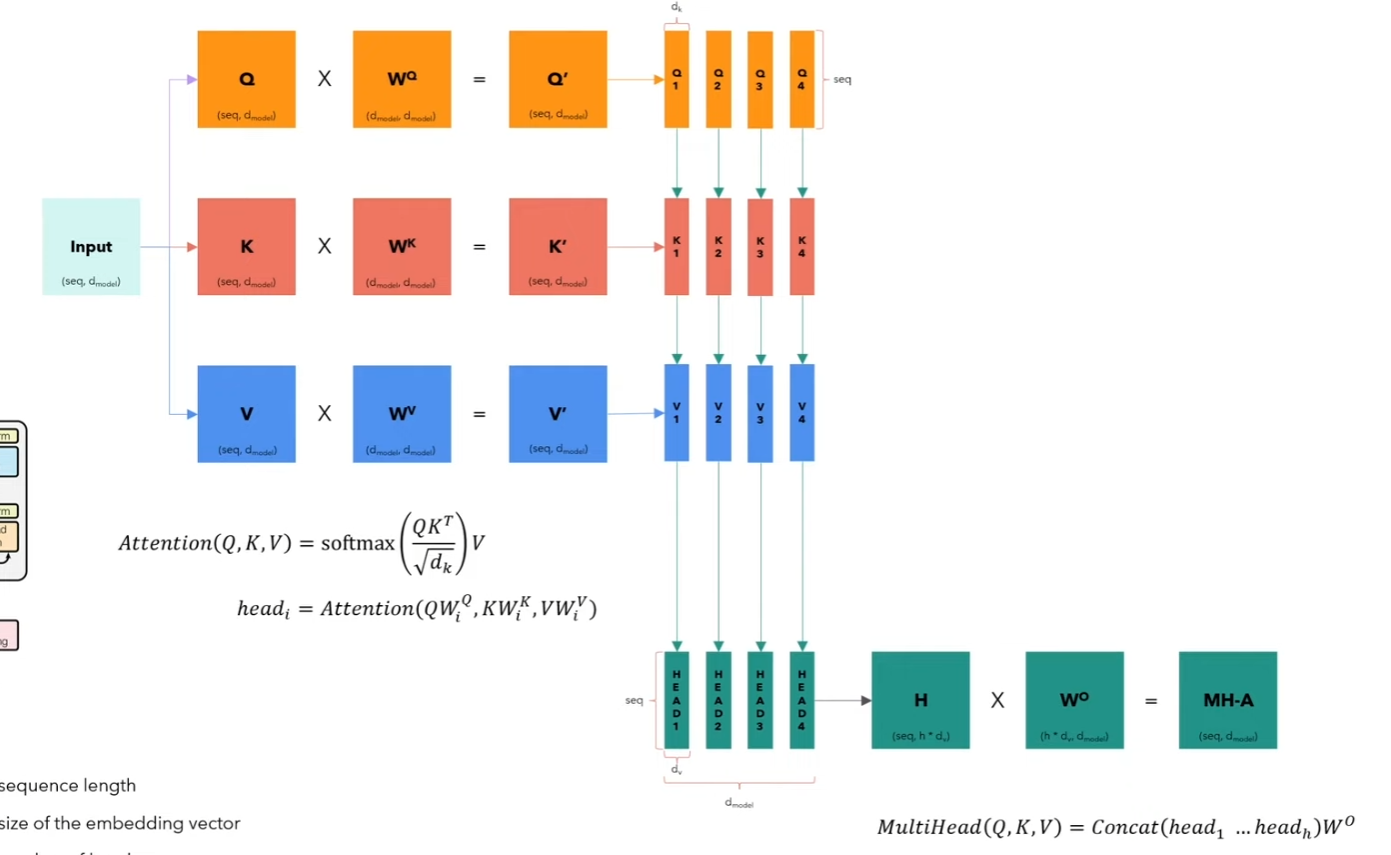

In [34]:
class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, d_model : int, h: int, dropout:float):
        super().__init__()
        self.d_model = d_model
        self.h = h
        assert d_model % h == 0, "d_model is not divisible by h"

        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)    
        
        self.w_o = nn.linear(h*d, d_model)     #h * d should be d_model but oh well
        self.dropout = nn.Dropout(dropout)

    @staticmethod 
    def attention(query, key, value, mask, dropout:nn.Dropout):
        dk = query.shape[-1]
        attention_scores = (query @ key.transpose(-2, -1)) /  math.sqrt(d_k)
        if mask is not None:
            attention_scores.masked_fill_(mask == 0, -1e9)

        #Applied column by column
        attention_scores = attention_scores.softmax(dim = -1)
        if dropout is not None:
            attention_scores = dropout(attention_score)

        return (attention_scores @ value), attention_score

    def forward(self, q, k, v, mask):
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)

        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2) 
        key =  key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2) 
        value =  value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)

        x, self.attention_scores = attention(query, key, value, mask, self.dropout)

        
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)

        return w_o * x

### Residual Connector

In [35]:
class ResidualConnection(nn.Module):

    def __init__(self, dropout:float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormailization()

    def forward(self, x, sublayer):
        #Combine original input with the layer specified
        return x + self.dropout(sublayer(self.norm(x)))

## Encoder Block & Decoder Block

In [37]:
class EncoderBlock(nn.Module):

    def __init__(self, self_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connetion = nn.ModuleList([ResidualConnection(dropout) for _ in range(2)])   #2 for now
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, src_mask):
        x = self.residual_connectionse[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_connectionse[1](x, self.feed_forward_block)
        return x

class Encoder(nn.Module):
    def __init__(self, layers: nn.ModuleList):
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization()

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

In [43]:
class DecoderBlock(nn.Module):
    def __init__(self, 
                 self_attention_block: MultiHeadAttentionBlock, 
                 cross_attention_block: MultiHeadAttentionBlock, 
                 feed_forward_block: FeedForwardBlock,
                 dropout: float
                ):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connetion = nn.ModuleList([ResidualConnection(dropout) for _ in range(3)])   #2 for now
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connetion[0](x, lambda x: self.self_attention_block(x,x,x, tgt_mask))
        x = self.residual_connetion[1](x, lambda x: self.self_attention_block(x,encoder_output,encoder_output, src_mask))
        x = self.residual_connetion[2](x, self.feed_forward_block)
        return x

class Decoder(nn.Module):
    def __init__(self, layers: nn.ModuleList):
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization()

    def forward(self, x, encoder_output, src_mark, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)

# Final Linear and Softmax (Projection Layer)

In [44]:
class ProjectionLayer(nn.Module):
    def __init__(self, d_model: int, vocab_size: int ):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return torch.log_softmax(self.proj(x), dim=-1)

## Building the final Transformer

In [46]:
class Transformer (nn.Module):

    def __init__(self, encoder: Encoder, decoder: Decoder, src_embed: InputEmbeddings, tgt_embed: InputEmbeddings,
                src_pos: PositionalEncoding, tgt_pos: PositionalEncoding, proj_layer: ProjectionLayer):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.proj_layer = proj_layer

    def encode(self, src, src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)

    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, tgt, tgt_mask)

    def proj(self, x,):
        return self.proj_layer(x)

In [47]:
def build_transformer(src_vocab_size: int, 
                      tgt_vocab_size: int, 
                      src_seq_len: int, 
                      tgt_seq_len: int,
                      d_model: int = 512,
                      N: int = 6,
                      h: int = 8,
                      dropout: float = 0.1,
                      d_ff: int = 2048
                     ) -> Transformer:
    src_embed = InputEmbeddings(d_model, src_vocab_size)
    tgt_embed = InputEmbeddings(d_model, tgt_vocab_size)

    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)

    encoder_blocks = []
    for _ in range(N):
        encoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_block = EncoderBlock(encoder_self_attention_block, feed_forward_block, dropout)
        encoder_blocks.append(encoder_block)

    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        decoder_cross_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_foward_blok = FeedForwardBlock(d_model, d_ff, dropout)
        decoder_block = DecoderBlock(decoder_self_attention_block, decoder_cross_attention_block, feed_forward_block, dropout)
        decoder_blocks.append(decoder_block)

    encoder = Encoder(nn.ModuleList(encoder_blocks))
    decoder = Decoder(nn.ModuleList(decoder_blocks))

    proj_layer = ProjectionLayer(d_model, tgt_vocab_size)

    transformer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, proj_layer)

    # Init parameters
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    return transformer

## Task: Translation Training and Validation